In [3]:
import torch
import torchvision
import torchvision.transforms.v2 as T

from Standardize import Standardize
from cifar10_models import build_deep_batch_normalized_model, build_deep_model, build_deep_model_with_alpha_dropout
from get_device import get_device
from graph_history import graph_history
from run_model import run_model
from torch.utils.data import DataLoader

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
train_and_valid_set = torchvision.datasets.CIFAR10(root="datasets", train=True, download=True, transform=toTensor)
test_set = torchvision.datasets.CIFAR10(root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_set, valid_set = torch.utils.data.random_split(train_and_valid_set, [45_000, 5_000])

batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size)
valid_loader = DataLoader(valid_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

all_images = torch.stack([img for img, _ in train_set])
standardize = Standardize(all_images)

Epoch:2 / 100, train loss: 2.1934, train metric: 0.1576, valid metric: 0.1912 (best) in 7.6s
Epoch:3 / 100, train loss: 2.0540, train metric: 0.2259, valid metric: 0.2476 (best) in 7.2s
Epoch:4 / 100, train loss: 1.9233, train metric: 0.2848, valid metric: 0.2874 (best) in 7.0s
Epoch:5 / 100, train loss: 1.8475, train metric: 0.3274, valid metric: 0.3544 (best) in 7.2s
Epoch:6 / 100, train loss: 1.8068, train metric: 0.3480, valid metric: 0.3534 in 7.1s
Epoch:7 / 100, train loss: 1.7344, train metric: 0.3727, valid metric: 0.3830 (best) in 7.0s
Epoch:8 / 100, train loss: 1.6807, train metric: 0.3933, valid metric: 0.3960 (best) in 7.0s
Epoch:9 / 100, train loss: 1.6566, train metric: 0.4021, valid metric: 0.3988 (best) in 7.2s
Epoch:10 / 100, train loss: 1.6166, train metric: 0.4164, valid metric: 0.4048 (best) in 7.1s
Epoch:11 / 100, train loss: 1.5895, train metric: 0.4296, valid metric: 0.4148 (best) in 7.1s
Epoch:12 / 100, train loss: 1.5704, train metric: 0.4355, valid metric: 0.4

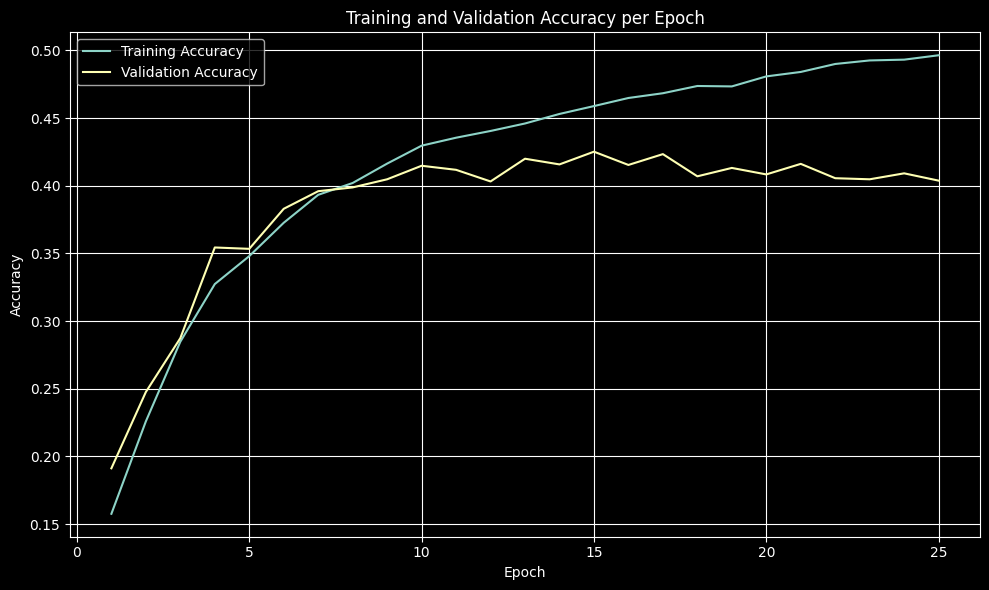

In [2]:
torch.manual_seed(42)
model = build_deep_model(n_hidden=20, n_neurons=100, n_inputs=3 * 32 * 32, n_outputs=10).to(get_device())
graph_history(run_model(model, train_loader, valid_loader))

Epoch:2 / 100, train loss: 1.9638, train metric: 0.2804, valid metric: 0.3428 (best) in 11.0s
Epoch:3 / 100, train loss: 1.6457, train metric: 0.4080, valid metric: 0.3428 (best) in 10.9s
Epoch:4 / 100, train loss: 1.5175, train metric: 0.4588, valid metric: 0.3920 (best) in 10.8s
Epoch:5 / 100, train loss: 1.4349, train metric: 0.4915, valid metric: 0.3854 in 10.9s
Epoch:6 / 100, train loss: 1.3680, train metric: 0.5134, valid metric: 0.3670 in 11.3s
Epoch:7 / 100, train loss: 1.3075, train metric: 0.5390, valid metric: 0.3780 in 11.4s
Epoch:8 / 100, train loss: 1.2597, train metric: 0.5571, valid metric: 0.3768 in 10.9s
Epoch:9 / 100, train loss: 1.2147, train metric: 0.5761, valid metric: 0.4198 (best) in 11.0s
Epoch:10 / 100, train loss: 1.1751, train metric: 0.5887, valid metric: 0.3944 in 10.9s
Epoch:11 / 100, train loss: 1.1341, train metric: 0.6041, valid metric: 0.4152 in 11.0s
Epoch:12 / 100, train loss: 1.1036, train metric: 0.6139, valid metric: 0.4358 (best) in 11.4s
Epoch

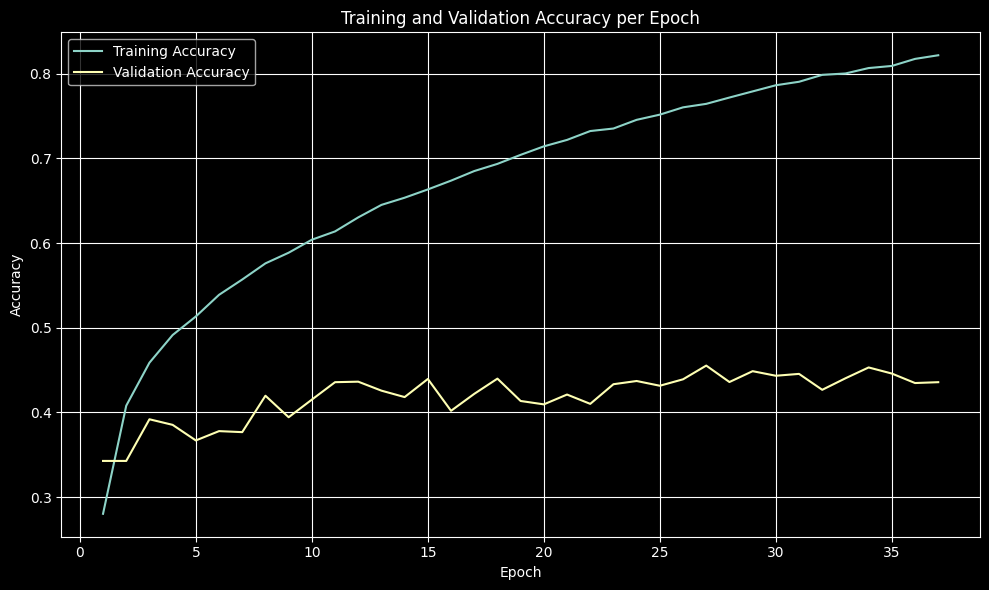

In [3]:
batch_normalized_model = build_deep_batch_normalized_model()
graph_history(run_model(batch_normalized_model, train_loader, valid_loader))

Epoch:2 / 100, train loss: 1.9942, train metric: 0.2797, valid metric: 0.3088 (best) in 7.9s
Epoch:3 / 100, train loss: 1.7790, train metric: 0.3632, valid metric: 0.3552 (best) in 7.7s
Epoch:4 / 100, train loss: 1.6799, train metric: 0.4015, valid metric: 0.3814 (best) in 7.7s
Epoch:5 / 100, train loss: 1.6012, train metric: 0.4308, valid metric: 0.3956 (best) in 7.5s
Epoch:6 / 100, train loss: 1.5532, train metric: 0.4549, valid metric: 0.4010 (best) in 7.7s
Epoch:7 / 100, train loss: 1.5104, train metric: 0.4670, valid metric: 0.4320 (best) in 7.5s
Epoch:8 / 100, train loss: 1.4743, train metric: 0.4838, valid metric: 0.4354 (best) in 7.6s
Epoch:9 / 100, train loss: 1.4432, train metric: 0.4949, valid metric: 0.4466 (best) in 7.6s
Epoch:10 / 100, train loss: 1.4115, train metric: 0.5080, valid metric: 0.4744 (best) in 7.7s
Epoch:11 / 100, train loss: 1.3826, train metric: 0.5171, valid metric: 0.4482 in 7.5s
Epoch:12 / 100, train loss: 1.3624, train metric: 0.5288, valid metric: 0.4

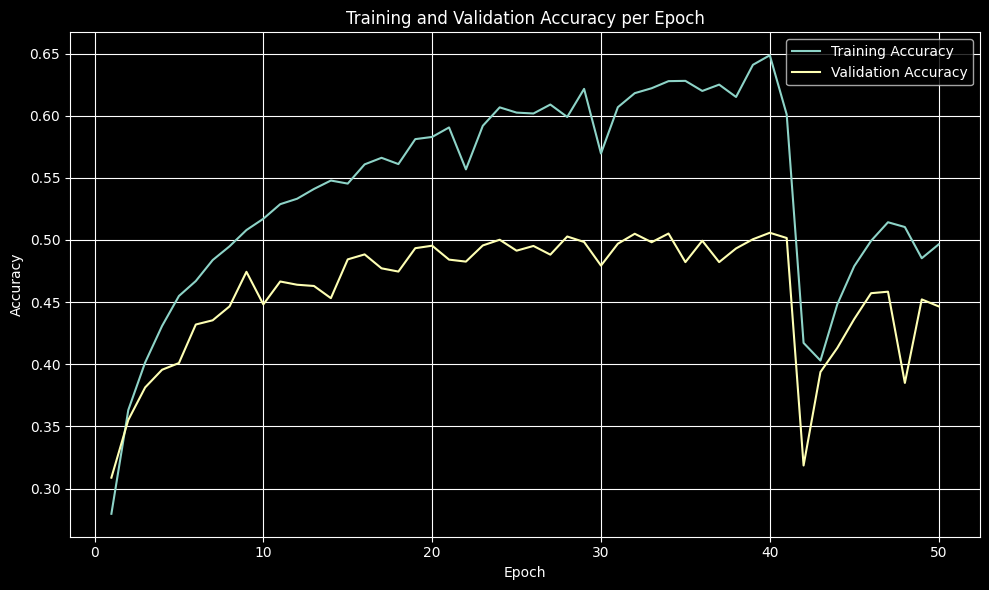

In [3]:
from cifar10_models import build_deep_model_with_selu
graph_history(run_model(build_deep_model_with_selu(standardize), train_loader, valid_loader))

Epoch:2 / 100, train loss: 2.1375, train metric: 0.1913, valid metric: 0.2098 (best) in 15.6s
Epoch:3 / 100, train loss: 1.9955, train metric: 0.2287, valid metric: 0.2068 in 8.1s
Epoch:4 / 100, train loss: 1.9328, train metric: 0.2611, valid metric: 0.2526 (best) in 11.9s
Epoch:5 / 100, train loss: 1.8986, train metric: 0.2708, valid metric: 0.2918 (best) in 10.1s
Epoch:6 / 100, train loss: 1.8915, train metric: 0.2743, valid metric: 0.2582 in 8.7s
Epoch:7 / 100, train loss: 1.8926, train metric: 0.2759, valid metric: 0.2780 in 8.5s
Epoch:8 / 100, train loss: 1.8961, train metric: 0.2856, valid metric: 0.2574 in 8.3s
Epoch:9 / 100, train loss: 1.8607, train metric: 0.2951, valid metric: 0.2656 in 8.2s
Epoch:10 / 100, train loss: 1.8629, train metric: 0.2933, valid metric: 0.2774 in 7.9s
Epoch:11 / 100, train loss: 1.8441, train metric: 0.3066, valid metric: 0.2978 (best) in 7.6s
Epoch:12 / 100, train loss: 1.8839, train metric: 0.2899, valid metric: 0.2490 in 7.8s
Epoch:13 / 100, trai

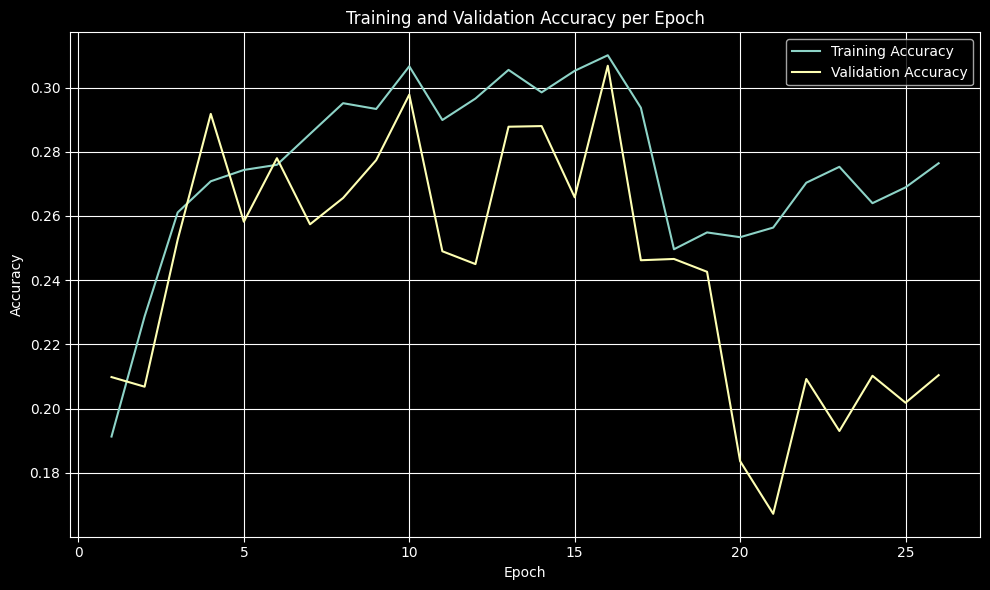

In [2]:
from cifar10_models import build_deep_model_with_alpha_dropout

graph_history(run_model(build_deep_model_with_alpha_dropout(standardize), train_loader, valid_loader),
              title='Training & Validation Per Epoch, Alpha Dropout, 0.1 Rate')

Epoch:2 / 100, train loss: 1.9951, train metric: 0.2808, valid metric: 0.2994 (best) in 8.5s
Epoch:3 / 100, train loss: 1.7879, train metric: 0.3589, valid metric: 0.3738 (best) in 7.9s
Epoch:4 / 100, train loss: 1.6863, train metric: 0.3989, valid metric: 0.4016 (best) in 7.8s
Epoch:5 / 100, train loss: 1.6306, train metric: 0.4221, valid metric: 0.3746 in 7.8s
Epoch:6 / 100, train loss: 1.5948, train metric: 0.4356, valid metric: 0.4246 (best) in 8.0s
Epoch:7 / 100, train loss: 1.5498, train metric: 0.4539, valid metric: 0.4416 (best) in 7.8s
Epoch:8 / 100, train loss: 1.5171, train metric: 0.4651, valid metric: 0.4488 (best) in 7.8s
Epoch:9 / 100, train loss: 1.4986, train metric: 0.4717, valid metric: 0.4234 in 8.3s
Epoch:10 / 100, train loss: 1.4686, train metric: 0.4840, valid metric: 0.4438 in 8.1s
Epoch:11 / 100, train loss: 1.4771, train metric: 0.4812, valid metric: 0.4384 in 8.1s
Epoch:12 / 100, train loss: 1.4444, train metric: 0.4927, valid metric: 0.4640 (best) in 8.6s
Ep

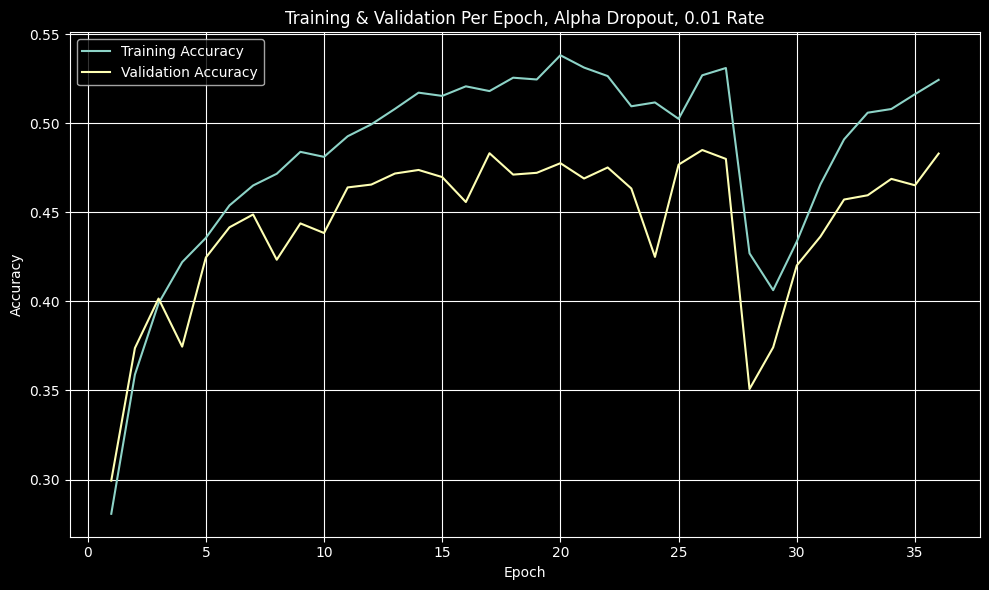

In [2]:
from cifar10_models import build_deep_model_with_alpha_dropout

graph_history(run_model(build_deep_model_with_alpha_dropout(standardize, dropout_rate=0.01), train_loader, valid_loader),
              title='Training & Validation Per Epoch, Alpha Dropout, 0.01 Rate')

Epoch:2 / 100, train loss: 1.9013, train metric: 0.3177, valid metric: 0.4040 (best) in 8.9s
Epoch:3 / 100, train loss: 1.6812, train metric: 0.4012, valid metric: 0.4350 (best) in 7.6s
Epoch:4 / 100, train loss: 1.5717, train metric: 0.4475, valid metric: 0.4634 (best) in 8.1s
Epoch:5 / 100, train loss: 1.4938, train metric: 0.4726, valid metric: 0.4662 (best) in 8.4s
Epoch:6 / 100, train loss: 1.4315, train metric: 0.4967, valid metric: 0.4706 (best) in 8.0s
Epoch:7 / 100, train loss: 1.3753, train metric: 0.5162, valid metric: 0.4784 (best) in 7.7s
Epoch:8 / 100, train loss: 1.3370, train metric: 0.5306, valid metric: 0.4850 (best) in 8.0s
Epoch:9 / 100, train loss: 1.2914, train metric: 0.5464, valid metric: 0.4870 (best) in 8.1s
Epoch:10 / 100, train loss: 1.2629, train metric: 0.5576, valid metric: 0.4934 (best) in 9.0s
Epoch:11 / 100, train loss: 1.2208, train metric: 0.5724, valid metric: 0.4966 (best) in 7.9s
Epoch:12 / 100, train loss: 1.1985, train metric: 0.5817, valid metr

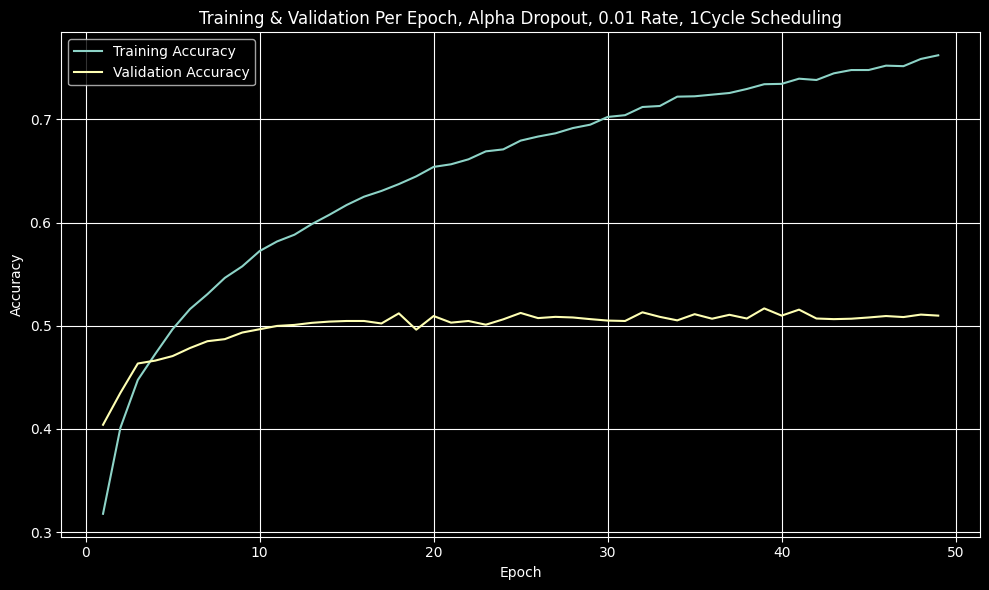

In [4]:
from run_model import run_model_1cycle_scheduling

graph_history(run_model_1cycle_scheduling(build_deep_model_with_alpha_dropout(standardize, dropout_rate=0.01), train_loader, valid_loader),
              title='Training & Validation Per Epoch, Alpha Dropout, 0.01 Rate, 1Cycle Scheduling')

Epoch:2 / 100, train loss: 2.2978, train metric: 0.1571, valid metric: 0.1970 (best) in 9.1s
Epoch:3 / 100, train loss: 2.0366, train metric: 0.2181, valid metric: 0.2378 (best) in 7.8s
Epoch:4 / 100, train loss: 1.9675, train metric: 0.2444, valid metric: 0.2616 (best) in 7.9s
Epoch:5 / 100, train loss: 1.9340, train metric: 0.2587, valid metric: 0.2666 (best) in 8.3s
Epoch:6 / 100, train loss: 1.8966, train metric: 0.2693, valid metric: 0.2890 (best) in 7.8s
Epoch:7 / 100, train loss: 1.8751, train metric: 0.2813, valid metric: 0.2936 (best) in 8.0s
Epoch:8 / 100, train loss: 1.8404, train metric: 0.2947, valid metric: 0.2908 in 7.7s
Epoch:9 / 100, train loss: 1.8073, train metric: 0.3092, valid metric: 0.3108 (best) in 8.1s
Epoch:10 / 100, train loss: 1.7717, train metric: 0.3200, valid metric: 0.2900 in 7.9s
Epoch:11 / 100, train loss: 1.7479, train metric: 0.3371, valid metric: 0.3280 (best) in 7.6s
Epoch:12 / 100, train loss: 1.7095, train metric: 0.3618, valid metric: 0.3514 (be

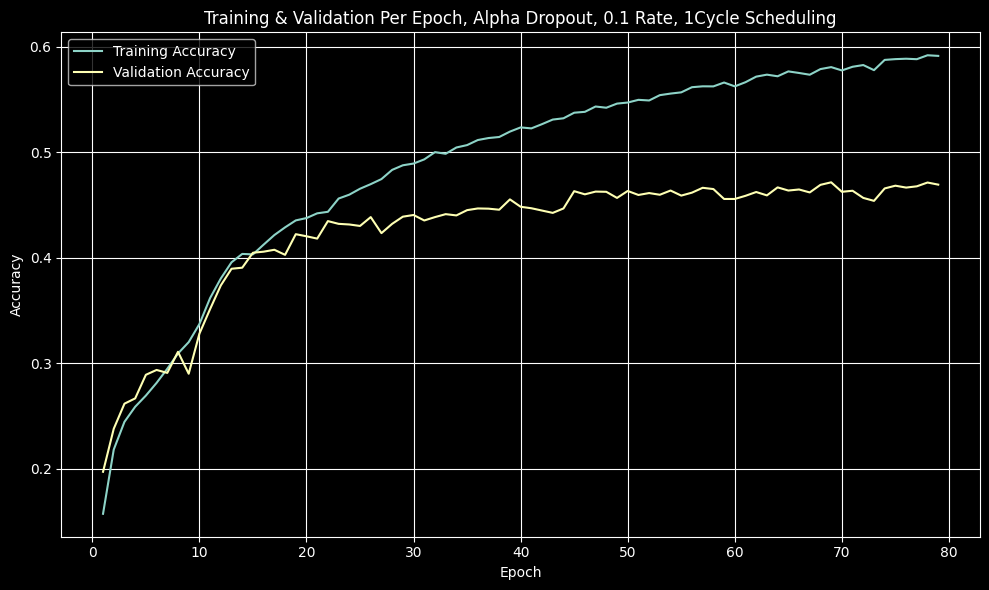

In [5]:
graph_history(run_model_1cycle_scheduling(build_deep_model_with_alpha_dropout(standardize, dropout_rate=0.1), train_loader, valid_loader),
              title='Training & Validation Per Epoch, Alpha Dropout, 0.1 Rate, 1Cycle Scheduling')